In [3]:
import scipy.stats as stats
import random
import torch
import torch
from torch.utils.data import DataLoader, Dataset, random_split
import os
import torch
from PIL import Image
from torchvision.transforms import transforms

In [4]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
print(device)

cuda


In [10]:
#cut tile
def cut_one_tile(img, tile_size=256):
    width, height= img.size
    if width < tile_size or height < tile_size:
        img = img.resize((tile_size, tile_size))
        return img
    x = random.randint(0, width-tile_size)
    y = random.randint(0, height-tile_size)
    tile=img.crop((x,y,x+tile_size,y+tile_size))
    return tile
#poisson
def poisson(input_image):
    scale=torch.empty(1).uniform_(30,120).item()
    image=torch.clamp(input_image.to(torch.float32),min=0.0)
    image0=image*scale
    noisy1=torch.poisson(image0)
    noisy1=noisy1/scale
    noisy1=torch.clamp(noisy1, 0.0,1.0)
    return noisy1
#row
def row(image):
    c,h,w = image.shape
    std=torch.empty(1).uniform_(0.0003, 0.0012).item()
    r=torch.randn(h)*std # normalised, uses std, [a,b,c], (,3)
    r=torch.unsqueeze(r,1)# (3,1)
    noisy3=image-r 
    noisy3=torch.clamp(noisy3,0.0,1.0)
    return noisy3
#read
def read(image):
    lam=torch.empty(1).uniform_(0,0.25).item()
    sigma=torch.empty(1).uniform_(0.0003, 0.0015).item()
    image_np1=image.numpy()
    noise1=stats.tukeylambda.rvs(lam=lam, loc=0, scale=sigma, size=image.shape)
    noisy_np1=image_np1+noise1
    noisy2=torch.from_numpy(noisy_np1).float()
    noisy2=torch.clamp(noisy2,0.0,1.0)
    return noisy2
#quantization
def quantization(image):
    bits=[10,11,12,12,14]
    bit_depth=random.choice(bits)
    q=1/(2**bit_depth -1) # quantization step
    adc=torch.round(image/q) # ADC level and choose an integral level
    noisy4=adc*q # back to image level
    noisy4=torch.clamp(noisy4,0.0,1.0)
    return noisy4
def add_synthetic_noise(image):
    r = random.random()
    if r < 0.40:
        noisy = poisson(image)                       
    elif r < 0.70:
        noisy = read(poisson(image))                 
    elif r < 0.75:
        noisy = row(read(poisson(image)))         
    elif r < 0.80:
        noisy = quantization(read(poisson(image))) 
    else:
        noisy = image                                
    return noisy

def star(input, stars=200, brightness=(150, 200)):   
    img = input.clone()
    c, h, w = img.shape  
    brightness_min = brightness[0] / 255.0
    brightness_max = brightness[1] / 255.0 
    x_coords = torch.randint(0, w, (stars,))
    y_coords = torch.randint(0, h, (stars,))
    brightnesses = torch.rand(stars) * (brightness_max - brightness_min) + brightness_min 
    img[:, y_coords, x_coords] = brightnesses.unsqueeze(0)
    return img

In [11]:
class AVdataset(Dataset):
    def __init__(self, input_images, crop_size=256, transforms=None): 
        self.input=input_images 
        self.crop=crop_size 
        self.imgnames=sorted(os.listdir(input_images))
    def __len__(self):
        return len(self.imgnames)

    def __getitem__(self, index):
        imgname=self.imgnames[index]
        path_in= os.path.join(self.input, imgname)
        im=Image.open(path_in).convert("RGB")#recieved error sometimes for channel number
        target_image=cut_one_tile(im)
        transformation1=transforms.ToTensor()
        image0=transformation1(target_image)
        # image1=poisson(image0)
        # image2=row(image1)
        # image3=read(image2)
        # noisy_image=quantization(image3)
        image1=star(image0, stars=100, brightness=(150,220))
        noisy_image=add_synthetic_noise(image1)
        return image1, noisy_image

In [12]:
import torch.nn as nn

def double_conv(input_channels, output_channels):
    convolutions=nn.Sequential(
        nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=3, stride=1, padding=1),
        nn.LeakyReLU(inplace=True),
        nn.Conv2d(in_channels=output_channels, out_channels=output_channels, kernel_size=3, stride=1, padding=1),
        nn.LeakyReLU(inplace=True)
        )
    return convolutions

class Unet(nn.Module):
    def __init__(self):
        super(Unet, self).__init__()
        self.maxpool=nn.MaxPool2d(kernel_size=2, stride=2 )
        self.dconv_1=double_conv(3,32)
        self.dconv_2=double_conv(32,64)
        self.dconv_3=double_conv(64,128)
        self.dconv_4=double_conv(128,256)
        self.dconv_5=double_conv(256,512)
        
        self.tconv_1=nn.ConvTranspose2d(in_channels=513, out_channels=256, kernel_size=2, stride=2)
        self.uconv_1=double_conv(512,256)
        self.tconv_2=nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.uconv_2=double_conv(256,128)
        self.tconv_3=nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.uconv_3=double_conv(128,64)
        self.tconv_4=nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.uconv_4=double_conv(64,32)
        self.uconv_5=nn.Conv2d(in_channels=32, out_channels=3, kernel_size=1, stride=1)
        
    def forward(self,image,etr):
        b=image.shape[0]
        
        #encoder
        x1=self.dconv_1(image)#
        x2=self.maxpool(x1)
        x3=self.dconv_2(x2)#
        x4=self.maxpool(x3)
        x5=self.dconv_3(x4)#
        x6=self.maxpool(x5)
        x7=self.dconv_4(x6)#
        x8=self.maxpool(x7)
        x9=self.dconv_5(x8)
        #bottleneck
        x10=torch.cat([x9,etr], dim=1)
        #decoder
        x11=self.tconv_1(x10)
        x12=torch.cat([x11,x7], dim=1)
        x13=self.uconv_1(x12)
        x14=self.tconv_2(x13)
        x15=torch.cat([x14,x5], dim=1)
        x16=self.uconv_2(x15)
        x17=self.tconv_3(x16)
        x18=torch.cat([x17,x3], dim=1)
        x19=self.uconv_3(x18)
        x20=self.tconv_4(x19)
        x21=torch.cat([x20,x1], dim=1)
        x22=self.uconv_4(x21)
        x23=self.uconv_5(x22)
        return x23


In [13]:
batch_size=10
learning_rate=1e-5
max_epochs=500

In [14]:
dataset_path="/kaggle/input/large-nasa-images/Input_images"
test_path="/kaggle/input/starfield-images/Starfield_Images"
dataset1=AVdataset(test_path)
dataset0= AVdataset(dataset_path)
train_dataset0, test_dataset0= random_split(dataset0, [584,146])
train_dataset1, test_dataset1= random_split(dataset1, [96,24])
train_dataset= train_dataset0+train_dataset1
test_dataset=test_dataset1+test_dataset0
train_loader= DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader= DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
model=Unet().to(device)

In [16]:
import torch.optim as optim
criterion=nn.L1Loss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [17]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import random
counter=0
loss_counter=0
best_loss = float("inf")
list_psnr=[]
list_ssim=[]
list_loss=[]
psnr_m = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_m = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
for epoch in range(max_epochs):

    #training part

    model.train()
    counter+=1
    for index, (target, noisy) in enumerate(train_loader):
        target=target.to(device)
        noisy=noisy.to(device)
        #forward
        b,c,h,w=target.shape
        etr = torch.empty(b).uniform_(5.0, 60.0).to(device)
        etr=etr.view((b,1,1,1)).expand((b,1,h//16,w//16))
        output = model(noisy, etr)
        #loss
        loss=criterion(output, target)
        #backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # evaluation part

    model.eval()
    loss_value=0
    psnr=0
    ssim=0
    with torch.no_grad():
        for target, noisy in test_loader:
            
            target=target.to(device)
            noisy=noisy.to(device)
            
            b,c,h,w = target.shape
            etr = torch.full((b,), 35).to(device)
            etr = etr.view((b,1,1,1)).expand((b,1,h//16,w//16))
            output = model(noisy, etr) 
            
            loss=criterion(output, target)
            loss_value+=loss.item()
            psnr+=psnr_m(output,target).item()
            ssim+=ssim_m(output,target).item()
            
    batches=len(test_loader)
    loss_value/=batches
    list_loss.append(loss_value)
    psnr/=batches
    ssim/=batches
    print(f"done with {counter} epochs and the loss was {loss_value}")

    if counter%10==0:
        list_psnr.append(psnr)
        list_ssim.append(ssim)
        
    if loss_value<best_loss:
        best_loss=loss_value
        torch.save(model.state_dict(),f"/kaggle/working/epoch_best_loss{counter}.pth")

    if len(list_loss)>=8:
        for i in list_loss[-7:]:
            if i>list_loss[-8]:
                loss_counter+=1
            else:
                loss_counter=0
        
    if loss_counter >= 7:
        print(f'caution!!!!! on {counter} epoch')

print(f'best_loss={best_loss}, psnr list={list_psnr}, ssim list={list_ssim}')


done with 1 epochs and the loss was 0.264035380061935
done with 2 epochs and the loss was 0.19192144406192443
done with 3 epochs and the loss was 0.12584838840891333
done with 4 epochs and the loss was 0.08270517824327245
done with 5 epochs and the loss was 0.07908395436756752
done with 6 epochs and the loss was 0.07186798926661997
done with 7 epochs and the loss was 0.07032295119236498
done with 8 epochs and the loss was 0.06751402029219795
done with 9 epochs and the loss was 0.060963628484922296
done with 10 epochs and the loss was 0.060601664597497266
done with 11 epochs and the loss was 0.05494702760787571
done with 12 epochs and the loss was 0.05479202353779007
done with 13 epochs and the loss was 0.05137978307902813
done with 14 epochs and the loss was 0.04962580519564012
done with 15 epochs and the loss was 0.04804030477124102
done with 16 epochs and the loss was 0.046533207354300166
done with 17 epochs and the loss was 0.04730542321853778
done with 18 epochs and the loss was 0.

KeyboardInterrupt: 

[0.264035380061935, 0.19192144406192443, 0.12584838840891333, 0.08270517824327245, 0.07908395436756752, 0.07186798926661997, 0.07032295119236498, 0.06751402029219795, 0.060963628484922296, 0.060601664597497266, 0.05494702760787571, 0.05479202353779007, 0.05137978307902813, 0.04962580519564012, 0.04804030477124102, 0.046533207354300166, 0.04730542321853778, 0.0479404110023204, 0.04445378087899264, 0.04388870802872321, 0.04620156974038657, 0.0426238869481227, 0.04067228624925894, 0.041176937410936636, 0.039609446464216005, 0.03954633675953921, 0.035474420744268334, 0.03310555438784992, 0.03108341104405768, 0.0315487449440886, 0.031081925036714357, 0.03163558973328156, 0.029694654047489166, 0.027929319178356844, 0.029672297703869203, 0.028583402526290977, 0.02846005734275369, 0.02892051637172699, 0.028415065587443465, 0.028234338990467435, 0.028103757266174343, 0.026300766450517318, 0.026826769442242736, 0.02731152158230543, 0.025872145834214547, 0.026988587396986344, 0.027013294782270405

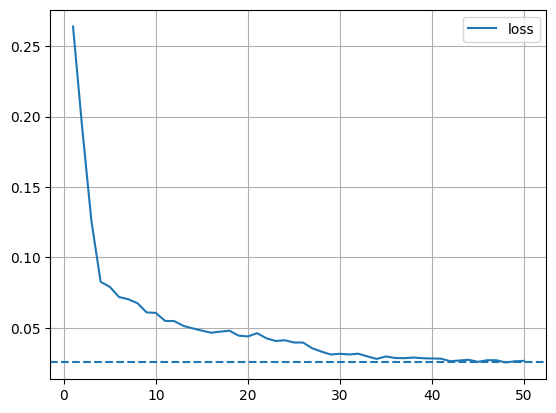

In [18]:
import matplotlib.pyplot as plt 
import numpy as np
print(list_loss)
epoch_x=np.arange(1, len(list_loss)+1, 1)
plt.plot(epoch_x, list_loss, label='loss')
plt.axhline(best_loss, linestyle='--')
plt.grid()
plt.legend()
plt.show()

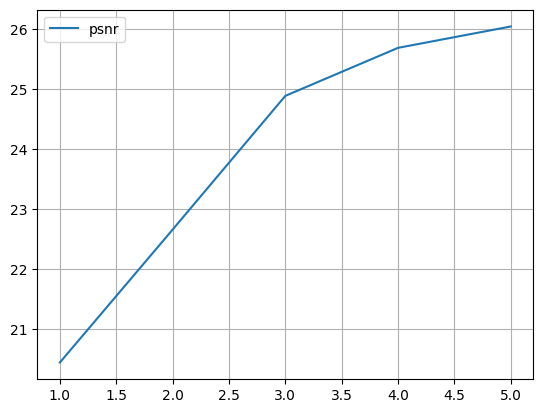

In [19]:
psnr_x=np.arange(1, len(list_psnr)+1, 1)
plt.plot(psnr_x, list_psnr, label='psnr')
plt.grid()
plt.legend()
plt.show()

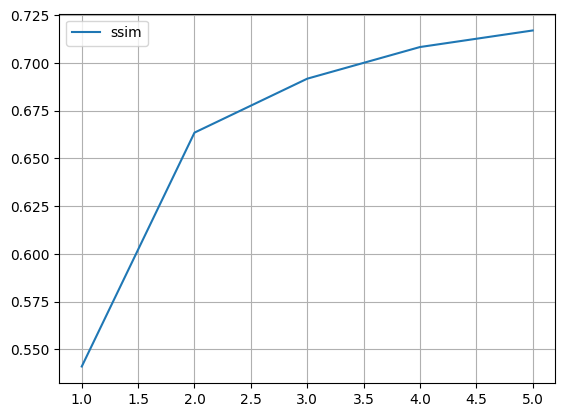

In [20]:
ssim_x=np.arange(1, len(list_ssim)+1, 1)
plt.plot(ssim_x, list_ssim, label='ssim')
plt.grid()
plt.legend()
plt.show()